In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xgboost as xgb

_NOTEBOOK_DIR = Path.cwd()
_PROJECT_ROOT = _NOTEBOOK_DIR
for _ in range(5):
    if (_PROJECT_ROOT / ".env").exists():
        break
    _PROJECT_ROOT = _PROJECT_ROOT.parent

sys.path.insert(0, str(_PROJECT_ROOT / "Models" / "Evaluation"))
sys.path.insert(0, str(_PROJECT_ROOT / "Models" / "Training"))

from utils import get_engine
from data_prep_batters import (
    load_batter_simulator_data,
    prepare_batter_features,
    train_val_test_split,
    load_batter_encoders,
    PITCH_RESULT_CLASSES,
    RESULT_TO_IDX,
    BUCKET_CLASS_NAMES,
    IMMEDIATE_PLUS_HIT_CLASSES,
    IMMEDIATE_PLUS_HIT_RESULT_TO_IDX,
    is_deciding_count,
    DECIDING_COUNTS,
)

In [2]:
_SAVED = _PROJECT_ROOT / "Models" / "Training" / "saved_models"
_MODELS = _PROJECT_ROOT / "Models" / "saved_models"

import json
import joblib

# Prefer pitch-level (12-class) model when artifacts exist; else legacy (5-bucket)
_enc_pl = _SAVED / "batter_encoders_pitch_level.json"
_model_pl = _SAVED / "batter_pitch_result_pitch_level_calibrated.joblib"
_classes_pl = _SAVED / "pitch_result_classes.json"
if not _enc_pl.exists():
    _enc_pl = _MODELS / "batter_encoders_pitch_level.json"
if not _model_pl.exists():
    _model_pl = _MODELS / "batter_pitch_result_pitch_level_calibrated.joblib"
if not _classes_pl.exists():
    _classes_pl = _MODELS / "pitch_result_classes.json"

use_pitch_level = _enc_pl.exists() and _model_pl.exists() and _classes_pl.exists()

if use_pitch_level:
    encoders = load_batter_encoders(_enc_pl)
    if encoders is None:
        encoders = json.loads(_enc_pl.read_text())
    model = joblib.load(_model_pl)
    # Prefer class list from encoders (saved with this model) so it matches model output
    if encoders.get("pitch_result_classes"):
        CLASS_NAMES = list(encoders["pitch_result_classes"])
    else:
        with open(_classes_pl) as f:
            CLASS_NAMES = json.load(f)
    print(f"Using pitch-level model ({len(CLASS_NAMES)}-class batter_pitch_result_pitch_level_calibrated.joblib).")
else:
    encoders = load_batter_encoders(_SAVED / "batter_encoders.json")
    if encoders is None:
        encoders = load_batter_encoders(_MODELS / "batter_encoders.json")
    if encoders is None:
        raise FileNotFoundError("batter_encoders.json not found")
    clf = xgb.XGBClassifier()
    model_path = _SAVED / "batter_pitch_result.json"
    if not model_path.exists():
        model_path = _MODELS / "batter_pitch_result.json"
    clf.load_model(str(model_path))
    cal_path = _SAVED / "batter_pitch_result_calibrated.joblib"
    if not cal_path.exists():
        cal_path = _MODELS / "batter_pitch_result_calibrated.joblib"
    model = joblib.load(cal_path)
    CLASS_NAMES = encoders.get("pitch_result_classes", BUCKET_CLASS_NAMES)
    print("Using calibrated model (batter_pitch_result_calibrated.joblib, 5-bucket legacy).")

feats = encoders["feats_batter"]
result_to_idx = encoders.get("result_to_idx", {r: i for i, r in enumerate(CLASS_NAMES)})
idx_to_result = {int(k): v for k, v in encoders.get("idx_to_result", {str(i): CLASS_NAMES[i] for i in range(len(CLASS_NAMES))}).items()}
print("Batter model and encoders loaded.")

Using calibrated model (batter_pitch_result_calibrated.joblib, 5-bucket legacy).
Batter model and encoders loaded.


In [3]:
engine = get_engine()
df = load_batter_simulator_data(engine)
_, _, test_df = train_val_test_split(df, train_frac=0.8, val_frac=0.1, random_state=42)

# When using pitch-level model: 4-class immediate or 5-class immediate+hit (ball, called_strike, swinging_strike, foul, hit)
use_immediate_plus_hit = use_pitch_level and len(CLASS_NAMES) == 5 and "hit" in CLASS_NAMES
use_immediate_outcomes_only = use_pitch_level and not use_immediate_plus_hit
X_test, y_test, _ = prepare_batter_features(
    test_df,
    cat_encodings=encoders["cat_encodings"],
    feature_cols=feats,
    use_pitch_result_target=use_pitch_level,
    use_immediate_outcomes_only=use_immediate_outcomes_only,
    use_immediate_plus_hit=use_immediate_plus_hit,
)
if np.issubdtype(y_test.dtype, np.integer):
    y_test_idx = y_test.astype(int)
else:
    y_test_idx = y_test.map(lambda r: result_to_idx.get(r, 0)).astype(int)

# Matchup = (batter, pitcher) for real-world evaluation
test_df = test_df.copy()
test_df["matchup"] = list(zip(test_df["batter"], test_df["pitcher"]))
# Rows aligned to predictions (subset when 5-bucket path filters by target_class)
test_eval = test_df.loc[X_test.index].copy()
print(f"Test set: {len(X_test)} pitches, {test_df['matchup'].nunique()} unique (batter, pitcher) matchups")
print(f"Target: {'pitch-level (' + str(len(CLASS_NAMES)) + '-class)' if use_pitch_level else '5-bucket at-bat outcome'}.")

Test set: 49820 pitches, 38913 unique (batter, pitcher) matchups
Target: 5-bucket at-bat outcome.


In [4]:
import pandas as pd

# Calculate raw counts and percentages
counts = pd.Series(y_test_idx).value_counts()
proportions = pd.Series(y_test_idx).value_counts(normalize=True) * 100

print("--- Actual Test Set Proportions ---")
print(f"Total Pitches Evaluated: {len(y_test_idx):,}\n")

for idx in counts.index:
    # Safely get the class name
    class_name = CLASS_NAMES[idx] if idx < len(CLASS_NAMES) else f"Class_{idx}"
    print(f"{class_name:<18}: {counts[idx]:>6,} pitches  ({proportions[idx]:>5.2f}%)")

--- Actual Test Set Proportions ---
Total Pitches Evaluated: 49,820

ball              : 19,529 pitches  (39.20%)
called_strike     : 14,176 pitches  (28.45%)
swinging_strike   :  6,543 pitches  (13.13%)
foul              :  6,273 pitches  (12.59%)
hit               :  3,299 pitches  ( 6.62%)


In [5]:
from sklearn.metrics import accuracy_score, log_loss

y_proba = model.predict_proba(X_test[feats])
n_model_classes = y_proba.shape[1]
# Post-hoc calibration: suppress foul and optionally boost hit to better match actual distribution.
CLASS_LIST = list(CLASS_NAMES)
if n_model_classes == 4 and "foul" in CLASS_LIST:
    _foul_idx = CLASS_LIST.index("foul")
    y_proba[:, _foul_idx] *= 0.70
    y_proba = y_proba / y_proba.sum(axis=1, keepdims=True)
elif n_model_classes == 5 and "foul" in CLASS_LIST and "hit" in CLASS_LIST:
    _foul_idx = CLASS_LIST.index("foul")
    _hit_idx = CLASS_LIST.index("hit")
    y_proba[:, _foul_idx] *= 0.70
    y_proba[:, _hit_idx] *= 1.3
    y_proba = y_proba / y_proba.sum(axis=1, keepdims=True)
weak_idx = encoders.get("weak_class_indices")
if weak_idx is not None:
    weak_idx = np.asarray(weak_idx)
    valid = weak_idx < n_model_classes
    weak_idx = weak_idx[valid]
if weak_idx is not None and len(weak_idx) > 0 and encoders.get("threshold_per_weak_class") is not None:
    # Per-class thresholds (one T per weak class); keep only for valid weak indices
    th_per = np.asarray(encoders["threshold_per_weak_class"])
    if len(th_per) >= len(weak_idx):
        th_per = th_per[: len(weak_idx)]
    else:
        th_per = np.resize(th_per, len(weak_idx))
    y_pred = np.argmax(y_proba, axis=1)
    for i in range(len(y_pred)):
        best_k, best_p = -1, -1.0
        for j, k in enumerate(weak_idx):
            if y_proba[i, k] >= th_per[j] and y_proba[i, k] > best_p:
                best_p = y_proba[i, k]
                best_k = k
        if best_k >= 0 and best_p >= y_proba[i, y_pred[i]]:
            y_pred[i] = best_k
elif encoders.get("threshold_weak") is not None and weak_idx is not None and len(weak_idx) > 0:
    # Single global threshold (legacy)
    pred = np.argmax(y_proba, axis=1)
    weak_proba = y_proba[:, weak_idx]
    weak_argmax_idx = np.argmax(weak_proba, axis=1)
    weak_max = np.max(weak_proba, axis=1)
    T = encoders["threshold_weak"]
    for i in range(len(pred)):
        if weak_max[i] >= T and weak_max[i] >= y_proba[i, pred[i]]:
            pred[i] = weak_idx[weak_argmax_idx[i]]
    y_pred = pred
else:
    y_pred = np.argmax(y_proba, axis=1)
acc = accuracy_score(y_test_idx, y_pred)
if n_model_classes != len(CLASS_NAMES):
    import warnings
    warnings.warn(
        f"Model has {n_model_classes} classes but CLASS_NAMES has {len(CLASS_NAMES)}. "
        "Using model's class count for metrics. Retrain and save the batter model to match your data (e.g. 6-class)."
    )
    if len(CLASS_NAMES) < n_model_classes:
        CLASS_NAMES = list(CLASS_NAMES) + [f"class_{i}" for i in range(len(CLASS_NAMES), n_model_classes)]
    else:
        CLASS_NAMES = CLASS_NAMES[:n_model_classes]
ll = log_loss(y_test_idx, y_proba, labels=np.arange(n_model_classes))
print("Overall (all test pitches):")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Log-loss:  {ll:.4f}")

Overall (all test pitches):
  Accuracy:  0.2595
  Log-loss:  8.1037


In [6]:
# 4-class immediate or 5-class immediate+hit (hit = successful hits only: 1b, 2b, 3b, hr lumped together)
EVAL_CLASS_NAMES = list(CLASS_NAMES) if (len(CLASS_NAMES) == 4 or (len(CLASS_NAMES) == 5 and "hit" in CLASS_NAMES)) else ["ball", "called_strike", "swinging_strike", "foul"]
y_test_4 = np.asarray(y_test_idx).ravel()
y_proba_4 = y_proba
y_pred_4 = y_pred
test_df_4 = test_df.loc[X_test.index].copy()
test_df_4["_pos"] = np.arange(len(test_df_4))
from sklearn.metrics import accuracy_score, log_loss
acc_4 = accuracy_score(y_test_4, y_pred_4)
ll_4 = log_loss(y_test_4, y_proba_4, labels=np.arange(len(EVAL_CLASS_NAMES)))
print(f"{len(EVAL_CLASS_NAMES)}-outcome evaluation ({', '.join(EVAL_CLASS_NAMES)}):")
print(f"  N pitches: {len(y_test_4):,}")
print(f"  Accuracy:  {acc_4:.4f}")
print(f"  Log-loss:  {ll_4:.4f}")

5-outcome evaluation (ball, called_strike, swinging_strike, foul, hit):
  N pitches: 49,820
  Accuracy:  0.2595
  Log-loss:  8.1037


In [7]:
# Predicted vs actual: cross-tab (counts and row-normalized %)
from sklearn.metrics import classification_report, confusion_matrix

# 5-outcome evaluation only
ct = pd.crosstab(y_test_4, y_pred_4, rownames=["Actual"], colnames=["Predicted"], margins=True)
ct.index = [EVAL_CLASS_NAMES[i] if isinstance(i, (int, np.integer)) and i < len(EVAL_CLASS_NAMES) else str(i) for i in ct.index]
ct.columns = [EVAL_CLASS_NAMES[i] if isinstance(i, (int, np.integer)) and i < len(EVAL_CLASS_NAMES) else str(i) for i in ct.columns]
print("Predicted vs actual (counts) — 4 outcomes:")
display(ct)

# Row-normalized: when actual was X, distribution of predictions
cm = confusion_matrix(y_test_4, y_pred_4, labels=np.arange(len(EVAL_CLASS_NAMES)))
cm_float = np.where(cm.sum(axis=1, keepdims=True) > 0, cm.astype(float) / cm.sum(axis=1, keepdims=True), 0)
ct_pct = pd.DataFrame(cm_float, index=EVAL_CLASS_NAMES, columns=EVAL_CLASS_NAMES)
print("\nWhen actual = X, predicted distribution (row-normalized %):")
display(ct_pct.round(3))

# Per-class metrics (precision, recall, F1, support)
report = classification_report(y_test_4, y_pred_4, labels=np.arange(len(EVAL_CLASS_NAMES)), target_names=EVAL_CLASS_NAMES, zero_division=0, output_dict=True)
report_df = pd.DataFrame(report).transpose()
print("\nPer-class metrics:")
display(report_df)

Predicted vs actual (counts) — 4 outcomes:


,ball,called_strike,swinging_strike,foul,hit,All
ball,7652,5731,1346,4190,610,19529
called_strike,5527,3505,2778,2197,169,14176
swinging_strike,4684,1034,245,532,48,6543
foul,2302,1546,312,913,1200,6273
hit,1208,853,165,461,612,3299
All,21373,12669,4846,8293,2639,49820



When actual = X, predicted distribution (row-normalized %):


,ball,called_strike,swinging_strike,foul,hit
ball,0.392,0.293,0.069,0.215,0.031
called_strike,0.390,0.247,0.196,0.155,0.012
swinging_strike,0.716,0.158,0.037,0.081,0.007
foul,0.367,0.246,0.050,0.146,0.191
hit,0.366,0.259,0.050,0.140,0.186



Per-class metrics:


,precision,recall,f1-score,support
ball,0.358022,0.391828,0.374163,19529.000000
called_strike,0.276660,0.247249,0.261129,14176.000000
swinging_strike,0.050557,0.037445,0.043024,6543.000000
foul,0.110093,0.145544,0.125360,6273.000000
hit,0.231906,0.185511,0.206130,3299.000000
accuracy,0.259474,0.259474,0.259474,0.259474
macro avg,0.205447,0.201515,0.201961,49820.000000
weighted avg,0.254922,0.259474,0.256056,49820.000000


In [8]:
# Matchup-level evaluation (4 outcomes only): restrict to matchups with at least N test pitches
import matplotlib.pyplot as plt
min_pitches = 20
groups = test_df_4.groupby(["batter", "pitcher"])
valid_matchups = [name for name, grp in groups if len(grp) >= min_pitches]

matchup_metrics = []
for (batter, pitcher) in valid_matchups:
    pos = test_df_4.loc[(test_df_4["batter"] == batter) & (test_df_4["pitcher"] == pitcher), "_pos"].values
    y_true_m = y_test_4[pos]
    y_pred_m = y_pred_4[pos]
    y_proba_m = y_proba_4[pos]
    n = len(y_true_m)
    acc_m = accuracy_score(y_true_m, y_pred_m)
    ll_m = log_loss(y_true_m, y_proba_m, labels=np.arange(len(EVAL_CLASS_NAMES)))
    matchup_metrics.append({"batter": batter, "pitcher": pitcher, "pitch_count": n, "accuracy": acc_m, "log_loss": ll_m})

matchup_df = pd.DataFrame(matchup_metrics)
if len(matchup_df) == 0:
    print(f"No matchups with >= {min_pitches} pitches.")
else:
    print("Per-matchup accuracy: mean = {:.4f}, median = {:.4f}, std = {:.4f}, min = {:.4f}, max = {:.4f}".format(
        matchup_df["accuracy"].mean(), matchup_df["accuracy"].median(), matchup_df["accuracy"].std(),
        matchup_df["accuracy"].min(), matchup_df["accuracy"].max()))
    print("Per-matchup log loss: mean = {:.4f}, median = {:.4f}, std = {:.4f}".format(
        matchup_df["log_loss"].mean(), matchup_df["log_loss"].median(), matchup_df["log_loss"].std()))
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    matchup_df["accuracy"].hist(ax=axes[0], bins=20, edgecolor="black", alpha=0.7)
    axes[0].set_xlabel("Accuracy"); axes[0].set_ylabel("Matchups"); axes[0].set_title("Per-matchup accuracy")
    matchup_df["log_loss"].hist(ax=axes[1], bins=20, edgecolor="black", alpha=0.7)
    axes[1].set_xlabel("Log loss"); axes[1].set_ylabel("Matchups"); axes[1].set_title("Per-matchup log loss")
    plt.tight_layout(); plt.show()
    print("\nTop 10 matchups by accuracy:")
    display(matchup_df.nlargest(10, "accuracy")[["batter", "pitcher", "pitch_count", "accuracy", "log_loss"]])
    print("Bottom 10 matchups by accuracy:")
    display(matchup_df.nsmallest(10, "accuracy")[["batter", "pitcher", "pitch_count", "accuracy", "log_loss"]])

No matchups with >= 20 pitches.


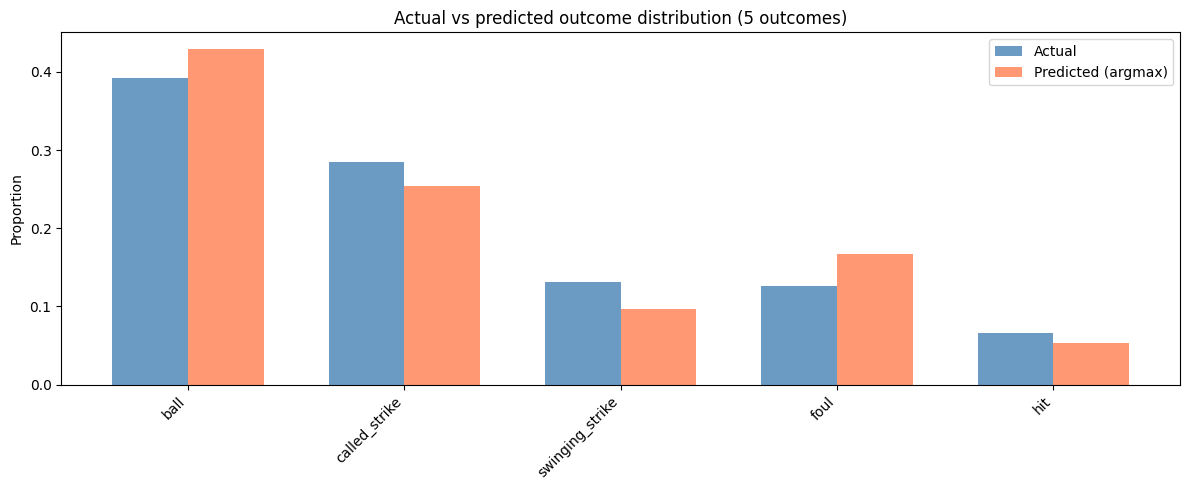

Actual vs predicted proportion by class (diff = pred - actual):


,actual_prop,pred_prop,diff_pred_minus_actual
ball,0.3920,0.4290,0.0370
called_strike,0.2845,0.2543,-0.0302
swinging_strike,0.1313,0.0973,-0.0341
foul,0.1259,0.1665,0.0405
hit,0.0662,0.0530,-0.0132


In [9]:
# Real vs predicted outcome distribution
actual_props = pd.Series(y_test_4).value_counts(normalize=True).reindex(np.arange(len(EVAL_CLASS_NAMES)), fill_value=0)
pred_props = pd.Series(y_pred_4).value_counts(normalize=True).reindex(np.arange(len(EVAL_CLASS_NAMES)), fill_value=0)
mean_proba = pd.Series(y_proba_4.mean(axis=0), index=np.arange(len(EVAL_CLASS_NAMES)))

x = np.arange(len(EVAL_CLASS_NAMES))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, actual_props.values, width, label="Actual", color="steelblue", alpha=0.8)
ax.bar(x + width/2, pred_props.values, width, label="Predicted (argmax)", color="coral", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(EVAL_CLASS_NAMES, rotation=45, ha="right")
ax.set_ylabel("Proportion"); ax.set_title(f"Actual vs predicted outcome distribution ({len(EVAL_CLASS_NAMES)} outcomes)")
ax.legend(); plt.tight_layout(); plt.show()

# Side-by-side: actual vs predicted proportion and difference per class
dist_table = pd.DataFrame({
    "actual_prop": actual_props.values,
    "pred_prop": pred_props.values,
    "diff_pred_minus_actual": pred_props.values - actual_props.values,
}, index=EVAL_CLASS_NAMES)
print("Actual vs predicted proportion by class (diff = pred - actual):")
display(dist_table.round(4))

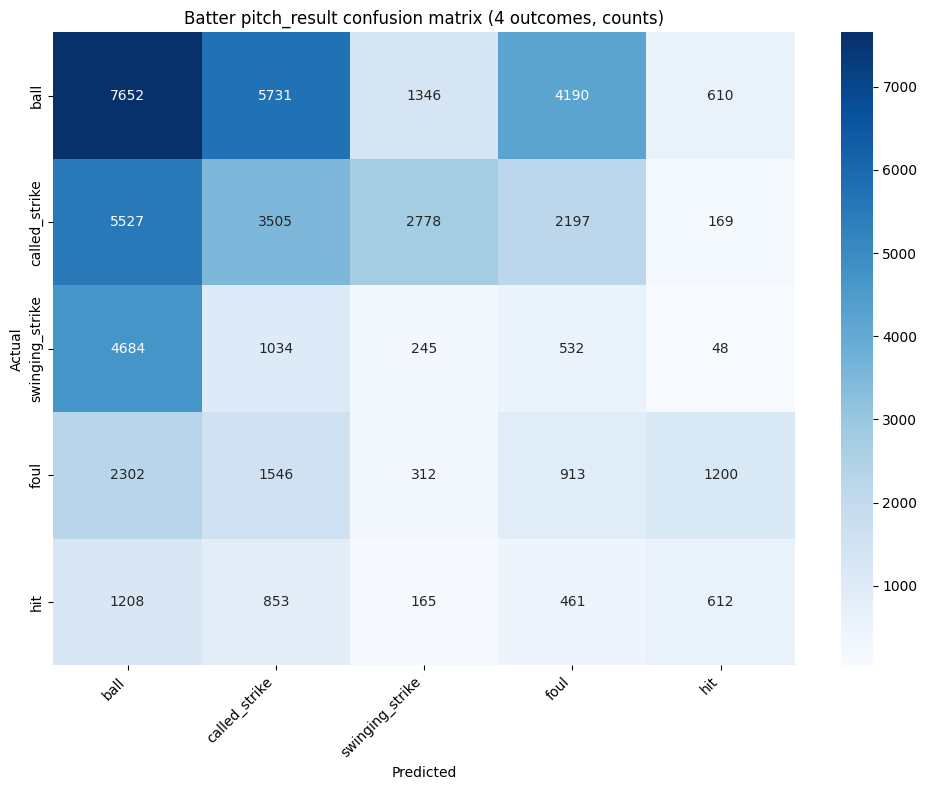

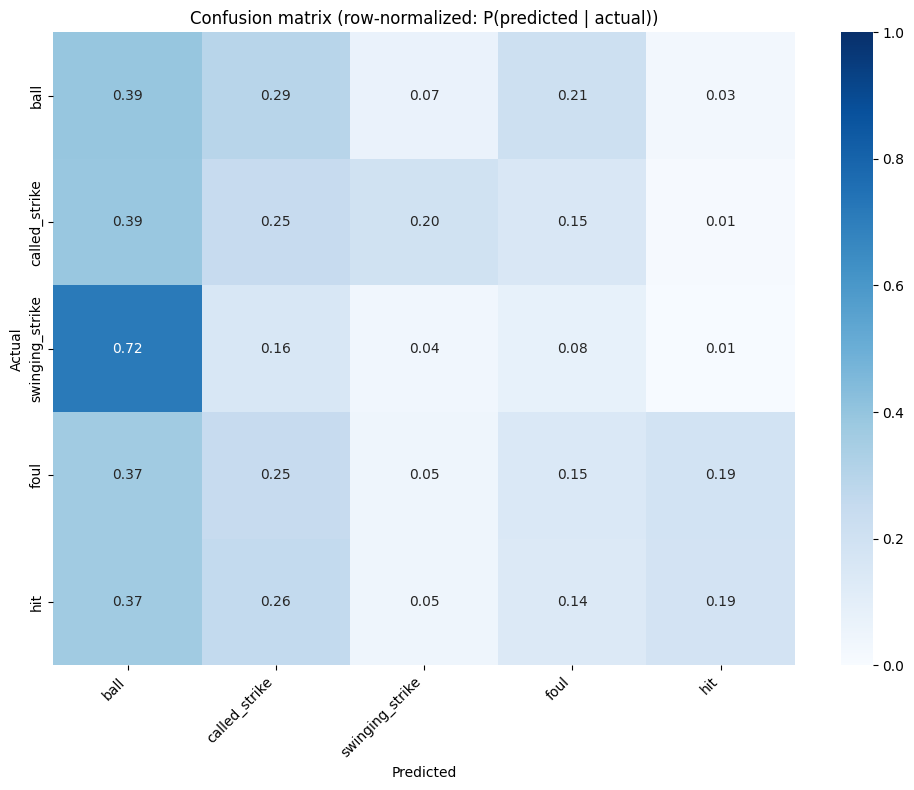

                 precision    recall  f1-score   support

           ball       0.36      0.39      0.37     19529
  called_strike       0.28      0.25      0.26     14176
swinging_strike       0.05      0.04      0.04      6543
           foul       0.11      0.15      0.13      6273
            hit       0.23      0.19      0.21      3299

       accuracy                           0.26     49820
      macro avg       0.21      0.20      0.20     49820
   weighted avg       0.25      0.26      0.26     49820



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test_4, y_pred_4, labels=np.arange(len(EVAL_CLASS_NAMES)))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, xticklabels=EVAL_CLASS_NAMES, yticklabels=EVAL_CLASS_NAMES, annot=True, fmt="d", ax=ax, cmap="Blues")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.title("Batter pitch_result confusion matrix (4 outcomes, counts)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Row-normalized confusion matrix: when actual = X, predicted distribution
cm_norm = cm.astype(float) / np.where(cm.sum(axis=1, keepdims=True) > 0, cm.sum(axis=1, keepdims=True), 1)
fig2, ax2 = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, xticklabels=EVAL_CLASS_NAMES, yticklabels=EVAL_CLASS_NAMES, annot=True, fmt=".2f", ax=ax2, cmap="Blues", vmin=0, vmax=1)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")
plt.title("Confusion matrix (row-normalized: P(predicted | actual))")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(classification_report(y_test_4, y_pred_4, labels=np.arange(len(EVAL_CLASS_NAMES)), target_names=EVAL_CLASS_NAMES, zero_division=0))

In [ ]:
# Stratified metrics (4 outcomes only): by count bucket, deciding vs non-deciding, and by pitch type
strat = test_df_4[["balls", "strikes", "pitch_type"]].copy()
strat["y_true"] = y_test_4
strat["y_pred"] = y_pred_4
strat["is_deciding"] = strat.apply(lambda row: is_deciding_count(row["balls"], row["strikes"]), axis=1)

# Indices for ball rate and strike rate (EVAL_CLASS_NAMES: 0=ball, 1=called_strike, 2=swinging_strike, 3=foul)
ball_idx = EVAL_CLASS_NAMES.index("ball") if "ball" in EVAL_CLASS_NAMES else None
strike_names = {"called_strike", "swinging_strike", "foul"}
strike_indices = [i for i, n in enumerate(EVAL_CLASS_NAMES) if n in strike_names]

# By count bucket: 0-0, 0-2, 3-2, other
def count_bucket(row):
    b, s = int(row["balls"]), int(row["strikes"])
    if b == 0 and s == 0: return "0-0"
    if b == 0 and s == 2: return "0-2"
    if b == 3 and s == 2: return "3-2"
    return "other"
strat["count_bucket"] = strat.apply(count_bucket, axis=1)
by_count = strat.groupby("count_bucket").apply(lambda g: pd.Series({
    "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
    "log_loss": log_loss(g["y_true"], y_proba_4[test_df_4.loc[g.index, "_pos"].values], labels=np.arange(len(EVAL_CLASS_NAMES))),
    "n": len(g)
}))
print("Accuracy and log loss by count bucket:")
display(by_count)

# Deciding vs non-deciding: accuracy, log loss, ball rate (actual vs predicted), strike rate (actual vs predicted)
def ball_rate_actual(y): return (y == ball_idx).mean() if ball_idx is not None else np.nan
def ball_rate_pred(y): return (y == ball_idx).mean() if ball_idx is not None else np.nan
def strike_rate_actual(y): return np.isin(y, strike_indices).mean() if strike_indices else np.nan
def strike_rate_pred(y): return np.isin(y, strike_indices).mean() if strike_indices else np.nan

by_deciding = strat.groupby("is_deciding").apply(lambda g: pd.Series({
    "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
    "log_loss": log_loss(g["y_true"], y_proba_4[test_df_4.loc[g.index, "_pos"].values], labels=np.arange(len(EVAL_CLASS_NAMES))),
    "n": len(g),
    "ball_rate_actual": ball_rate_actual(g["y_true"].values),
    "ball_rate_pred": ball_rate_pred(g["y_pred"].values),
    "strike_rate_actual": strike_rate_actual(g["y_true"].values),
    "strike_rate_pred": strike_rate_pred(g["y_pred"].values),
}))
by_deciding = by_deciding.rename(index={False: "non_deciding", True: "deciding"})
print("\nDeciding vs non-deciding (deciding = 3-2, 0-2, 1-2, 2-2, 3-1):")
display(by_deciding)

# By (balls, strikes) for key counts
key_counts = [(0, 0), (0, 2), (1, 2), (2, 2), (3, 2), (3, 1)]
strat["count_str"] = strat.apply(lambda r: f"{int(r['balls'])}-{int(r['strikes'])}", axis=1)
key_strs = [f"{b}-{s}" for b, s in key_counts]
strat_key = strat[strat["count_str"].isin(key_strs)]
if len(strat_key) > 0:
    by_bs = strat_key.groupby("count_str").apply(lambda g: pd.Series({
        "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
        "n": len(g),
        "ball_rate_actual": ball_rate_actual(g["y_true"].values),
        "ball_rate_pred": ball_rate_pred(g["y_pred"].values),
    })).reindex(key_strs)
    print("\nAccuracy and ball rate by key count (balls-strikes):")
    display(by_bs)

# By pitch type
if "pitch_type" in strat.columns:
    by_pitch = strat.groupby("pitch_type").apply(lambda g: pd.Series({
        "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
        "n": len(g)
    })).sort_values("n", ascending=False)
    print("\nAccuracy by pitch type:")
    display(by_pitch)

In [ ]:
from sqlalchemy import text
from utils import get_engine  # or however you get the engine in your notebook

engine = get_engine()
with engine.connect() as conn:
    df = conn.execute(text("""
        SELECT "type", events, description
        FROM clean_statcast_with_batter
        WHERE "type" = 'X'
        LIMIT 20
    """)).fetchall()
    for row in df:
        print(row)

In [ ]:
# Calibration (only when using calibrated model)
try:
    _cal = using_calibrated
except NameError:
    _cal = False
if not _cal:
    print("N/A (uncalibrated model).")
else:
    from sklearn.metrics import brier_score_loss
    n_classes = len(EVAL_CLASS_NAMES)
    brier_per_class = []
    for k in range(n_classes):
        y_bin = (y_test_4 == k).astype(int)
        proba_k = y_proba_4[:, k]
        brier_per_class.append(brier_score_loss(y_bin, proba_k))
    brier_series = pd.Series(brier_per_class, index=EVAL_CLASS_NAMES)
    print("Brier score per class (4 outcomes; lower is better):")
    display(brier_series.sort_values())